In [1]:
import numpy as np
import matplotlib.pyplot as plt


### Helper Functions


In [2]:
def center_data(X):
    """Subtract the mean from each feature."""
    return X - X.mean(axis=0)

def cov_matrix(X):
    """Compute covariance matrix."""
    X = np.asarray(X, dtype=float)
    Xc = X - X.mean(axis=0)
    return (Xc.T @ Xc) / (len(X) - 1)

def pca_project(X, n_components=2):
    """PCA: eigendecomposition of covariance matrix, project to top components."""
    Xc = center_data(X)
    S = cov_matrix(X)
    eigvals, eigvecs = np.linalg.eigh(S)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    W = eigvecs[:, :n_components]
    Z = Xc @ W
    ratios = eigvals / eigvals.sum()
    return Z, eigvecs, eigvals, ratios

def poly_kernel(X, Y, degree=3, coef0=1.0):
    """Polynomial kernel: K(x,y) = (x^T y + c)^d."""
    return (np.asarray(X) @ np.asarray(Y).T + coef0) ** degree

def gaussian_kernel(X, Y, sigma=1.0):
    """Gaussian kernel: K(x,y) = exp(-||x-y||^2 / 2*sigma^2)."""
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)
    X_sq = np.sum(X**2, axis=1).reshape(-1, 1)
    Y_sq = np.sum(Y**2, axis=1).reshape(1, -1)
    return np.exp(-(X_sq + Y_sq - 2 * X @ Y.T) / (2 * sigma**2))

def center_kernel(K):
    """Center kernel matrix in feature space."""
    n = K.shape[0]
    one_n = np.ones((n, n)) / n
    return K - one_n @ K - K @ one_n + one_n @ K @ one_n

def kpca_project(X, kernel_func, n_components=2, **kernel_params):
    """Kernel PCA: build kernel matrix, center, eigendecompose, project."""
    K = kernel_func(X, X, **kernel_params)
    Kc = center_kernel(K)
    eigvals, eigvecs = np.linalg.eigh(Kc)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    # Normalize and project
    pos = eigvals > 1e-10
    alpha = eigvecs[:, :n_components] / np.sqrt(np.maximum(eigvals[:n_components], 1e-10))
    Z = Kc @ alpha
    ratios = eigvals[pos] / eigvals[pos].sum()
    return Z, eigvals, ratios


In [3]:
def plot_pca_vectors(X, eigvecs, eigvals, title="PCA"):
    """Plot data with principal component directions."""
    mu = X.mean(axis=0)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(X[:, 0], X[:, 1], s=30, alpha=0.6)
    
    data_range = max(X[:, 0].max() - X[:, 0].min(), X[:, 1].max() - X[:, 1].min())
    
    for i, (vec, val) in enumerate(zip(eigvecs.T[:2], eigvals[:2])):
        ratio = val / eigvals[0]
        scale = data_range * 0.35 * ratio
        color = ['red', 'blue'][i]
        end = mu + vec * scale
        ax.annotate('', xy=end, xytext=mu,
                     arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
        ax.text(end[0] + data_range*0.03, end[1] + data_range*0.03,
                f"PC{i+1} ({val:.2f})", color=color, fontsize=10, fontweight='bold')
    
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=13)
    ax.grid(True, alpha=0.3)
    return fig, ax

def plot_comparison(X, Z_pca, Z_kpca, pca_ratios, kpca_ratios, title="", colors=None):
    """Side-by-side: original data, PCA 1D projection, KPCA 1D projection."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    c = colors if colors is not None else 'steelblue'
    
    # Original data
    axes[0].scatter(X[:, 0], X[:, 1], c=c, s=30, alpha=0.7, edgecolors='white', linewidths=0.3)
    axes[0].set_title("Original Data", fontsize=12)
    axes[0].grid(True, alpha=0.3)
    
    # PCA: plot as 1D strip (index vs PC1) when PC1 dominates, else 2D scatter
    if pca_ratios[0] > 0.9:
        # PC1 dominates: show 1D projection
        order = np.argsort(Z_pca[:, 0])
        axes[1].scatter(Z_pca[order, 0], np.zeros_like(Z_pca[:, 0]),
                        c=np.array(c)[order] if isinstance(c, np.ndarray) else c,
                        s=40, alpha=0.7, edgecolors='white', linewidths=0.3)
        axes[1].set_xlabel(f"PC1 ({pca_ratios[0]*100:.1f}%)", fontsize=11)
        axes[1].set_yticks([])
        axes[1].set_ylim(-1, 1)
    else:
        axes[1].scatter(Z_pca[:, 0], Z_pca[:, 1], c=c, s=30, alpha=0.7,
                        edgecolors='white', linewidths=0.3)
        axes[1].set_xlabel(f"PC1 ({pca_ratios[0]*100:.1f}%)", fontsize=11)
        axes[1].set_ylabel(f"PC2 ({pca_ratios[1]*100:.1f}%)", fontsize=11)
    axes[1].axhline(0, c='gray', lw=0.5); axes[1].axvline(0, c='gray', lw=0.5)
    axes[1].set_title("PCA Projection", fontsize=12)
    axes[1].grid(True, alpha=0.3)
    
    # KPCA
    if kpca_ratios[0] > 0.9:
        order = np.argsort(Z_kpca[:, 0])
        axes[2].scatter(Z_kpca[order, 0], np.zeros_like(Z_kpca[:, 0]),
                        c=np.array(c)[order] if isinstance(c, np.ndarray) else c,
                        s=40, alpha=0.7, edgecolors='white', linewidths=0.3)
        axes[2].set_xlabel(f"KPC1 ({kpca_ratios[0]*100:.1f}%)", fontsize=11)
        axes[2].set_yticks([])
        axes[2].set_ylim(-1, 1)
    else:
        axes[2].scatter(Z_kpca[:, 0], Z_kpca[:, 1], c=c, s=30, alpha=0.7,
                        edgecolors='white', linewidths=0.3)
        axes[2].set_xlabel(f"KPC1 ({kpca_ratios[0]*100:.1f}%)", fontsize=11)
        axes[2].set_ylabel(f"KPC2 ({kpca_ratios[1]*100:.1f}%)", fontsize=11)
    axes[2].axhline(0, c='gray', lw=0.5); axes[2].axvline(0, c='gray', lw=0.5)
    axes[2].set_title("Kernel PCA Projection", fontsize=12)
    axes[2].grid(True, alpha=0.3)
    
    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


### Interactive PCA: Why This Direction?

PCA finds the direction that maximizes the variance of projected data. Use the slider below to rotate the projection axis and observe how the projected variance changes. The red direction is PCA's optimal choice — you can verify that no other angle gives higher variance.

In [ ]:
%matplotlib widget
import ipywidgets as widgets
from IPython.display import display

# Generate data
np.random.seed(0)
X_demo = np.random.uniform(0, 10, size=(30, 2))
X_demo[:, 1] = 0.5 * X_demo[:, 0] + np.random.uniform(-0.5, 0.5, 30)
X_c = X_demo - X_demo.mean(axis=0)
mu = X_demo.mean(axis=0)

# PCA solution
S = cov_matrix(X_demo)
eigvals, eigvecs = np.linalg.eigh(S)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]; eigvecs = eigvecs[:, idx]
pca_angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

# Precompute variance for all angles
angles = np.linspace(0, 180, 361)
variances = []
for a in angles:
    rad = np.radians(a)
    w = np.array([np.cos(rad), np.sin(rad)])
    proj = X_c @ w
    variances.append(np.var(proj))
variances = np.array(variances)

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plt.subplots_adjust(bottom=0.25)

# Left: data + projection direction + projected points
scatter = ax1.scatter(X_demo[:, 0], X_demo[:, 1], c='steelblue', s=40, alpha=0.7, zorder=3)
line, = ax1.plot([], [], 'r-', lw=2.5, label='Projection direction')
proj_scatter = ax1.scatter([], [], c='tomato', s=30, alpha=0.8, zorder=4, marker='o')
drop_lines = []
for _ in range(len(X_demo)):
    dl, = ax1.plot([], [], 'gray', lw=0.5, alpha=0.3)
    drop_lines.append(dl)
ax1.set_xlim(-2, 12); ax1.set_ylim(-2, 7)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.2)
ax1.set_title("Data and Projection", fontsize=12)
ax1.legend(fontsize=9)
var_text = ax1.text(0.02, 0.95, '', transform=ax1.transAxes, fontsize=11,
                     verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Right: variance vs angle
ax2.plot(angles, variances, 'b-', lw=1.5, label='Projected variance')
ax2.axvline(pca_angle % 180, color='red', linestyle='--', lw=1.5, label=f'PCA direction ({pca_angle:.1f}°)')
marker, = ax2.plot([], [], 'ro', markersize=10, zorder=5)
ax2.set_xlabel('Projection Angle (°)', fontsize=12)
ax2.set_ylabel('Variance', fontsize=12)
ax2.set_title('Variance vs Projection Angle', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

def update(angle):
    rad = np.radians(angle)
    w = np.array([np.cos(rad), np.sin(rad)])
    
    # Projection line through mean
    t = np.linspace(-15, 15, 2)
    line.set_data(mu[0] + t * w[0], mu[1] + t * w[1])
    
    # Project centered data onto direction, then map back to original space
    proj_vals = X_c @ w
    proj_pts = mu + np.outer(proj_vals, w)
    proj_scatter.set_offsets(proj_pts)
    
    # Drop lines from original to projected
    for j, dl in enumerate(drop_lines):
        dl.set_data([X_demo[j, 0], proj_pts[j, 0]], [X_demo[j, 1], proj_pts[j, 1]])
    
    # Variance
    var = np.var(proj_vals)
    var_text.set_text(f'Angle: {angle:.0f}°\nVariance: {var:.3f}')
    
    # Marker on variance curve
    marker.set_data([angle % 180], [variances[int((angle % 180) / 180 * 360)]])
    
    fig.canvas.draw_idle()

slider = widgets.FloatSlider(value=pca_angle % 180, min=0, max=180, step=1,
                              description='Angle (°):', layout=widgets.Layout(width='80%'))
widgets.interact(update, angle=slider)
plt.show()


In [ ]:
%matplotlib inline


### Dataset 1: Linear Relationship

$y \approx 0.5x + \text{noise}$ — PCA should capture this well since the structure is linear.


Data shape: (30, 2)

Covariance matrix:
[[8.2   4.026]
 [4.026 2.068]]

Eigenvalues: [10.1946  0.0736]
Explained variance: 99.3%, 0.7%
PC1 direction: [-0.896, -0.444]

KPCA top eigenvalues: [5.13979749e+06 2.17135700e+04 3.88445000e+03 4.10400000e+01
 1.16700000e+01]
KPCA explained variance: 99.5%, 0.4%


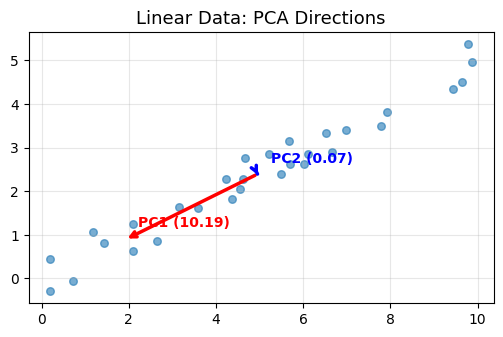

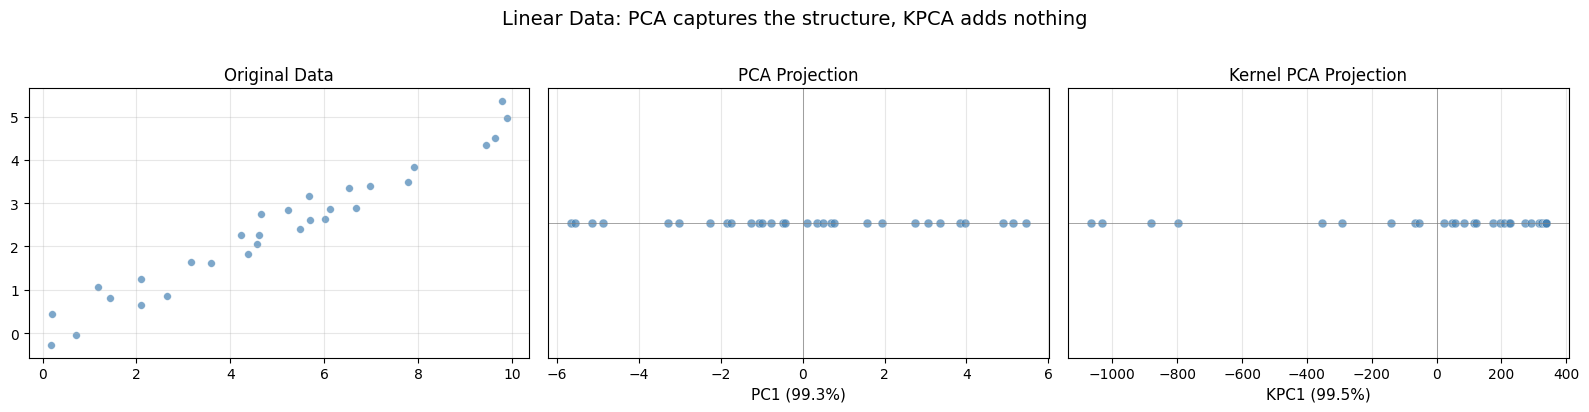

In [4]:
np.random.seed(0)
data_1 = np.random.uniform(0, 10, size=(30, 2))
data_1[:, 1] = 0.5 * data_1[:, 0] + np.random.uniform(-0.5, 0.5, 30)

print(f"Data shape: {data_1.shape}")

# PCA
S = cov_matrix(data_1)
print(f"\nCovariance matrix:\n{S.round(3)}")

Z_pca, eigvecs, eigvals, pca_ratios = pca_project(data_1)
print(f"\nEigenvalues: {eigvals.round(4)}")
print(f"Explained variance: {pca_ratios[0]*100:.1f}%, {pca_ratios[1]*100:.1f}%")
print(f"PC1 direction: [{eigvecs[0,0]:.3f}, {eigvecs[1,0]:.3f}]")

# KPCA
Z_kpca, kpca_eigvals, kpca_ratios = kpca_project(data_1, poly_kernel, degree=3, coef0=1.0)
print(f"\nKPCA top eigenvalues: {kpca_eigvals[:5].round(2)}")
print(f"KPCA explained variance: {kpca_ratios[0]*100:.1f}%, {kpca_ratios[1]*100:.1f}%")

plot_pca_vectors(data_1, eigvecs, eigvals, "Linear Data: PCA Directions")
plt.show()

plot_comparison(data_1, Z_pca, Z_kpca, pca_ratios, kpca_ratios,
                "Linear Data: PCA captures the structure, KPCA adds nothing")


### Dataset 2: Quadratic Relationship

$y \approx x^2 + \text{noise}$ — the data lies on a curve. PCA finds a straight line through a curve, which is suboptimal.


Data shape: (50, 2)

Covariance matrix:
[[ 8.146  2.323]
 [ 2.323 61.302]]

Eigenvalues: [61.4037  8.0442]
Explained variance: 88.4%, 11.6%
PC1 direction: [0.044, 0.999]

KPCA top eigenvalues: [1.11383972e+09 1.70820565e+08 2.09580900e+05 3.15294000e+04
 2.30626000e+03]
KPCA explained variance: 86.7%, 13.3%


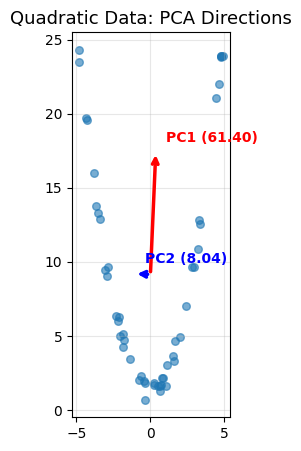

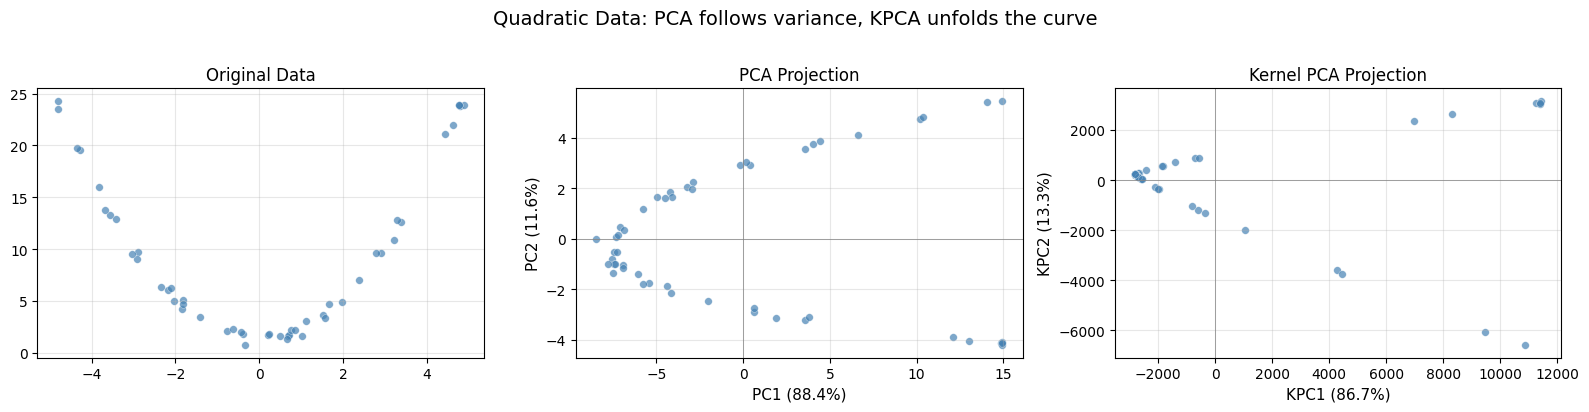

In [5]:
np.random.seed(0)
data_2 = np.random.uniform(-5, 5, size=(50, 2))
data_2[:, 1] = data_2[:, 0]**2 + np.random.uniform(0, 2, 50)

print(f"Data shape: {data_2.shape}")

# PCA
S = cov_matrix(data_2)
print(f"\nCovariance matrix:\n{S.round(3)}")

Z_pca, eigvecs, eigvals, pca_ratios = pca_project(data_2)
print(f"\nEigenvalues: {eigvals.round(4)}")
print(f"Explained variance: {pca_ratios[0]*100:.1f}%, {pca_ratios[1]*100:.1f}%")
print(f"PC1 direction: [{eigvecs[0,0]:.3f}, {eigvecs[1,0]:.3f}]")

# KPCA
Z_kpca, kpca_eigvals, kpca_ratios = kpca_project(data_2, poly_kernel, degree=3, coef0=1.0)
print(f"\nKPCA top eigenvalues: {kpca_eigvals[:5].round(2)}")
print(f"KPCA explained variance: {kpca_ratios[0]*100:.1f}%, {kpca_ratios[1]*100:.1f}%")

plot_pca_vectors(data_2, eigvecs, eigvals, "Quadratic Data: PCA Directions")
plt.show()

plot_comparison(data_2, Z_pca, Z_kpca, pca_ratios, kpca_ratios,
                "Quadratic Data: PCA follows variance, KPCA unfolds the curve")


### Dataset 3: Concentric Rings

Three classes arranged as concentric rings — no linear projection can separate them. This is where KPCA should clearly outperform PCA.


Data shape: (115, 2)
Classes: 35 inner, 45 middle, 35 outer

PCA eigenvalues: [10.0604  7.6095]
PCA explained variance: 56.9%, 43.1%

KPCA sigma: 2.0
KPCA top 5 eigenvalues: [17.6569 13.9416  9.9995  6.7353  5.2438]
KPCA explained variance: 19.6%, 15.4%


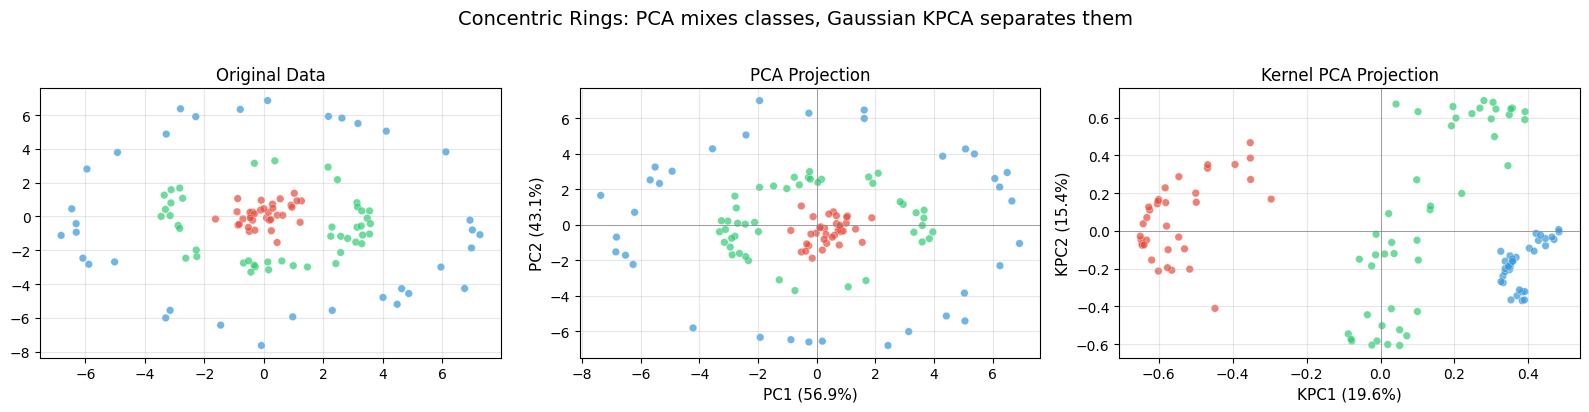

In [6]:
rng = np.random.default_rng(0)

n1, n2, n3 = 35, 45, 35
inner = rng.normal(0, 0.7, size=(n1, 2))

theta_mid = rng.uniform(0, 2*np.pi, n2)
r_mid = rng.normal(3.2, 0.35, n2)
middle = np.c_[r_mid * np.cos(theta_mid), r_mid * np.sin(theta_mid)]

theta_out = rng.uniform(0, 2*np.pi, n3)
r_out = rng.normal(6.6, 0.45, n3)
outer = np.c_[r_out * np.cos(theta_out), r_out * np.sin(theta_out)]

data_rings = np.vstack([inner, middle, outer])
labels = np.array([0]*n1 + [1]*n2 + [2]*n3)
ring_colors = np.array(['#e74c3c', '#2ecc71', '#3498db'])[labels]

print(f"Data shape: {data_rings.shape}")
print(f"Classes: {n1} inner, {n2} middle, {n3} outer")

# PCA
Z_pca, eigvecs, eigvals, pca_ratios = pca_project(data_rings)
print(f"\nPCA eigenvalues: {eigvals.round(4)}")
print(f"PCA explained variance: {pca_ratios[0]*100:.1f}%, {pca_ratios[1]*100:.1f}%")

# KPCA with Gaussian kernel
sigma = 2.0
Z_kpca, kpca_eigvals, kpca_ratios = kpca_project(data_rings, gaussian_kernel, sigma=sigma)
print(f"\nKPCA sigma: {sigma}")
print(f"KPCA top 5 eigenvalues: {kpca_eigvals[:5].round(4)}")
print(f"KPCA explained variance: {kpca_ratios[0]*100:.1f}%, {kpca_ratios[1]*100:.1f}%")

plot_comparison(data_rings, Z_pca, Z_kpca, pca_ratios, kpca_ratios,
                "Concentric Rings: PCA mixes classes, Gaussian KPCA separates them",
                colors=ring_colors)


### Dataset 4: Two Moons

Two interleaving half-circles — another classic nonlinear separation problem.


Data shape: (200, 2)
Classes: 100 class 0, 100 class 1

PCA eigenvalues: [0.8384 0.1903]
PCA explained variance: 81.5%, 18.5%

KPCA sigma: 0.5
KPCA top 5 eigenvalues: [35.8077 28.2807 24.463  16.0536 15.1793]
KPCA explained variance: 22.8%, 18.0%


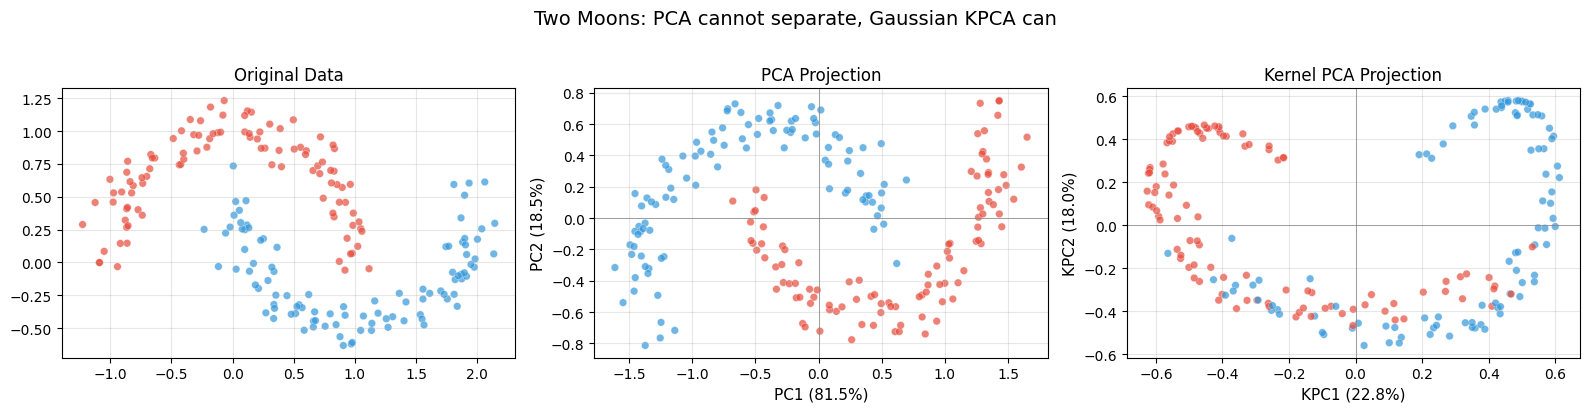

In [7]:
from sklearn.datasets import make_moons
X_moons, y_moons = make_moons(n_samples=200, noise=0.1, random_state=42)
moon_colors = np.array(['#e74c3c', '#3498db'])[y_moons]

print(f"Data shape: {X_moons.shape}")
print(f"Classes: {np.sum(y_moons==0)} class 0, {np.sum(y_moons==1)} class 1")

# PCA
Z_pca, _, eigvals, pca_ratios = pca_project(X_moons)
print(f"\nPCA eigenvalues: {eigvals.round(4)}")
print(f"PCA explained variance: {pca_ratios[0]*100:.1f}%, {pca_ratios[1]*100:.1f}%")

# KPCA with Gaussian kernel
sigma = 0.5
Z_kpca, kpca_eigvals, kpca_ratios = kpca_project(X_moons, gaussian_kernel, sigma=sigma)
print(f"\nKPCA sigma: {sigma}")
print(f"KPCA top 5 eigenvalues: {kpca_eigvals[:5].round(4)}")
print(f"KPCA explained variance: {kpca_ratios[0]*100:.1f}%, {kpca_ratios[1]*100:.1f}%")

plot_comparison(X_moons, Z_pca, Z_kpca, pca_ratios, kpca_ratios,
                "Two Moons: PCA cannot separate, Gaussian KPCA can",
                colors=moon_colors)


### Summary

| Dataset | Structure | PCA | KPCA |
|---------|-----------|-----|------|
| Linear | $y = 0.5x + \text{noise}$ | Captures well | No advantage |
| Quadratic | $y = x^2 + \text{noise}$ | Follows variance direction | Better unfolding of the curve |
| Concentric Rings | Circular clusters | Classes mixed | Classes separated |
| Two Moons | Interleaving arcs | Classes mixed | Classes separated |

PCA works well when the data structure is linear. KPCA provides a clear advantage only when the data has inherent nonlinear structure that cannot be captured by any linear projection.
